# Movie Recommender System
two approaches: user-based collaborative filtering and SVD matrix factorization
working with synthetic ratings data (similar to movielens format)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
# movie list
movies = [
    'Inception', 'The Dark Knight', 'Interstellar', 'Avengers',
    'The Godfather', 'Pulp Fiction', 'Forrest Gump', 'The Matrix',
    'Goodfellas', 'Titanic', 'Jurassic Park', 'Toy Story',
    'Shawshank Redemption', 'Schindlers List', 'Silence of the Lambs',
    'Gladiator', 'Braveheart', 'Lion King', 'Saving Private Ryan', 'Alien'
]

n_users = 200
n_movies = len(movies)

# create sparse rating matrix
ratings = np.zeros((n_users, n_movies))

for u in range(n_users):
    n_rated = np.random.randint(3, 12)
    rated = np.random.choice(n_movies, n_rated, replace=False)
    scores = np.random.choice([1,2,3,4,5], n_rated, p=[0.05,0.1,0.2,0.35,0.3])
    ratings[u, rated] = scores

df = pd.DataFrame(ratings, columns=movies,
                  index=[f'user_{i+1}' for i in range(n_users)])

sparsity = (df == 0).sum().sum() / df.size
print(f"matrix shape: {df.shape}")
print(f"sparsity: {sparsity:.1%}")
df.head(3)

matrix shape: (200, 20)
sparsity: 64.2%


,Inception,The Dark Knight,Interstellar,Avengers,The Godfather,Pulp Fiction,Forrest Gump,The Matrix,Goodfellas,Titanic,Jurassic Park,Toy Story,Shawshank Redemption,Schindlers List,Silence of the Lambs,Gladiator,Braveheart,Lion King,Saving Private Ryan,Alien
user_1,1.0,4.0,0.0,4.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,5.0,1.0,0.0
user_2,2.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,1.0,3.0
user_3,4.0,0.0,5.0,0.0,5.0,0.0,3.0,4.0,5.0,0.0,4.0,1.0,0.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0


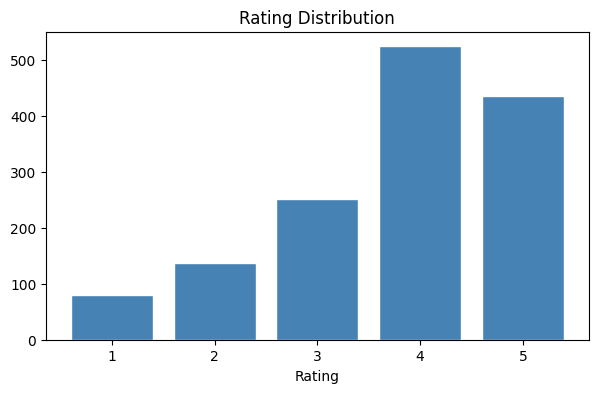

Most rated movies:
Toy Story          85
Schindlers List    84
Alien              79
The Dark Knight    78
Forrest Gump       77
dtype: int64


In [3]:
# rating distribution
all_ratings = ratings[ratings > 0].flatten()

plt.figure(figsize=(7,4))
plt.hist(all_ratings, bins=[0.5,1.5,2.5,3.5,4.5,5.5], color='steelblue',
         edgecolor='white', rwidth=0.8)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.xticks([1,2,3,4,5])
plt.show()

# most rated movies
counts = (df > 0).sum().sort_values(ascending=False)
print("Most rated movies:")
print(counts.head(5))

In [4]:
# user-based collaborative filtering
# find users similar to target user, recommend what they liked

def get_recommendations(user_id, df, n_similar=5, n_recs=5):
    matrix = df.values
    sim = cosine_similarity(matrix)  # similarity between all users

    user_idx = df.index.get_loc(user_id)
    sim_scores = sim[user_idx].copy()
    sim_scores[user_idx] = 0  # ignore self similarity

    top_users = np.argsort(sim_scores)[::-1][:n_similar]

    # movies this user hasn't seen
    unseen = np.where(matrix[user_idx] == 0)[0]

    scores = {}
    for m in unseen:
        weighted = 0
        total_w = 0
        for su in top_users:
            r = matrix[su, m]
            if r > 0:
                w = sim_scores[su]
                weighted += w * r
                total_w += w
        if total_w > 0:
            scores[m] = weighted / total_w

    top_movies = sorted(scores, key=scores.get, reverse=True)[:n_recs]
    return [(df.columns[m], round(scores[m], 2)) for m in top_movies]


test_user = 'user_1'
seen = df.loc[test_user][df.loc[test_user] > 0].index.tolist()
print(f"\n{test_user} has watched: {seen}")
print(f"\nRecommendations:")
for movie, score in get_recommendations(test_user, df):
    print(f"  {movie} - predicted rating: {score}")


user_1 has watched: ['Inception', 'The Dark Knight', 'Avengers', 'Pulp Fiction', 'Goodfellas', 'Toy Story', 'Gladiator', 'Lion King', 'Saving Private Ryan']

Recommendations:
  Silence of the Lambs - predicted rating: 5.0
  Interstellar - predicted rating: 4.0
  Jurassic Park - predicted rating: 3.97
  Alien - predicted rating: 3.49
  Shawshank Redemption - predicted rating: 3.0


In [5]:
# SVD approach - matrix factorization
# first mean-center the ratings
R = ratings.copy().astype(float)
for i in range(R.shape[0]):
    mask = R[i] > 0
    if mask.any():
        R[i, mask] -= R[i, mask].mean()

svd = TruncatedSVD(n_components=10, random_state=42)
R_reduced = svd.fit_transform(R)
R_approx = svd.inverse_transform(R_reduced)

# how good is the reconstruction on known ratings?
mask = ratings > 0
rmse = np.sqrt(mean_squared_error(ratings[mask], R_approx[mask]))
print(f"SVD reconstruction RMSE: {rmse:.4f}")
print(f"variance explained: {svd.explained_variance_ratio_.sum():.4f}")

SVD reconstruction RMSE: 3.8226
variance explained: 0.6914


In [6]:
# SVD recommendations for user 0
user_idx = 0
predicted_all = R_approx[user_idx]
unseen_mask = ratings[user_idx] == 0

svd_scores = [(movies[i], round(predicted_all[i], 3))
               for i in range(len(movies)) if unseen_mask[i]]
svd_scores.sort(key=lambda x: x[1], reverse=True)

print("SVD recommendations for user_1:")
for movie, score in svd_scores[:5]:
    print(f"  {movie}: {score}")

SVD recommendations for user_1:
  Silence of the Lambs: 0.396
  Shawshank Redemption: 0.335
  Forrest Gump: 0.043
  Braveheart: -0.129
  The Matrix: -0.286
